<a href="https://colab.research.google.com/github/Baronlegend27/academic-research-to-financial-freedom/blob/main/papers/Anarkulova%2C%20A.%2C%20Cederburg%2C%20S.%2C%20%26%20O%E2%80%99Doherty%2C%20M.%20S.%20(2024).%20Beyond%20the%20status%20quo%20A%20critical%20assessment%20of%20lifecycle%20investment%20advice/Bootstrap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The purpose of this notebook is to demonstrate why block bootstrap methods can produce materially different portfolio simulation results than IID bootstrap by preserving the serial correlation present in historical market returns.

[*********************100%***********************]  3 of 3 completed


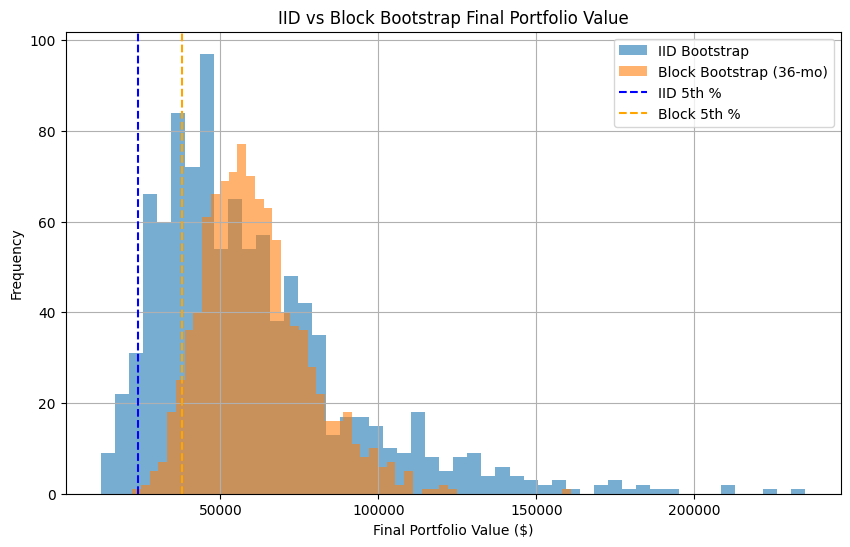

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.tsa.stattools as ts

# Fetch historical data
tickers = ["SPY", "VEA", "BND"]
data = yf.download(tickers, period="max", auto_adjust=True)["Close"]

# Monthly returns
returns = data.resample("ME").last().pct_change().dropna()
returns_np = returns[["SPY", "VEA", "BND"]].values

# Parameters
initial_investment = 10000
years = 30
months = years * 12
sim_count = 1000
equity_weight = 0.5  # example allocation for demonstration

# -------------------
# IID Bootstrap
# -------------------
iid_final = []
iid_returns_all = []  # Store simulated returns to analyze serial correlation

for _ in range(sim_count):
    sampled_indices = np.random.randint(0, returns_np.shape[0], size=months)
    sampled_returns = returns_np[sampled_indices]

    ret_equity = 0.5 * sampled_returns[:,0] + 0.5 * sampled_returns[:,1]
    ret_bonds = sampled_returns[:,2]
    monthly_ret = equity_weight * ret_equity + (1 - equity_weight) * ret_bonds

    wealth = initial_investment * np.cumprod(1 + monthly_ret)
    iid_final.append(wealth[-1])

    iid_returns_all.append(monthly_ret)

iid_final = np.array(iid_final)
iid_returns_all = np.array(iid_returns_all)

# -------------------
# Block Bootstrap (36-month blocks)
# -------------------
block_size = 36
num_blocks = int(np.ceil(months / block_size))
block_final = []
block_returns_all = []  # Store simulated returns to analyze serial correlation

for _ in range(sim_count):
    block_indices = np.random.randint(0, returns_np.shape[0] - block_size, size=num_blocks)
    sampled_blocks = np.vstack([returns_np[i:i+block_size] for i in block_indices])
    sampled_blocks = sampled_blocks[:months]  # trim excess if needed

    ret_equity = 0.5 * sampled_blocks[:,0] + 0.5 * sampled_blocks[:,1]
    ret_bonds = sampled_blocks[:,2]
    monthly_ret = equity_weight * ret_equity + (1 - equity_weight) * ret_bonds

    wealth = initial_investment * np.cumprod(1 + monthly_ret)
    block_final.append(wealth[-1])

    block_returns_all.append(monthly_ret)

block_final = np.array(block_final)
block_returns_all = np.array(block_returns_all)

# -------------------
# Plot distributions
# -------------------
plt.figure(figsize=(10,6))
plt.hist(iid_final, bins=50, alpha=0.6, label="IID Bootstrap")
plt.hist(block_final, bins=50, alpha=0.6, label="Block Bootstrap (36-mo)")
plt.axvline(np.percentile(iid_final, 5), color='blue', linestyle='dashed', label="IID 5th %")
plt.axvline(np.percentile(block_final, 5), color='orange', linestyle='dashed', label="Block 5th %")
plt.title("IID vs Block Bootstrap Final Portfolio Value")
plt.xlabel("Final Portfolio Value ($)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()



This code downloads historical price data for SPY, VEA, and BND, converts the prices to monthly returns, and uses those returns to run Monte Carlo simulations of a 30-year portfolio. Two resampling methods are compared: an IID bootstrap, which randomly samples individual months of returns, and a block bootstrap, which samples multi-month blocks of returns to preserve market time structure. After running 1,000 simulations for each method, the code plots the distributions of final portfolio values, allowing a visual comparison of how the two bootstrap approaches affect simulated long-term outcomes.

In [2]:
from scipy.stats import ks_2samp

D_stat, p_value = ks_2samp(iid_final, block_final)
print(f"KS test D-statistic: {D_stat:.4f}, p-value: {p_value:.4f}")

KS test D-statistic: 0.2360, p-value: 0.0000


The Kolmogorov–Smirnov test indicated a statistically significant difference between the distributions (D = 0.191, p < 0.001), suggesting that the observed distributions differ meaningfully.

In [3]:
# Print some stats
print("IID Bootstrap 5th percentile:", np.percentile(iid_final,5))
print("Block Bootstrap 5th percentile:", np.percentile(block_final,5))
print("IID Median:", np.median(iid_final))
print("Block Median:", np.median(block_final))
print("IID 1st percentile:", np.percentile(iid_final, 1))
print("Block 1st percentile:", np.percentile(block_final, 1))
print("IID final wealth std dev:", np.std(iid_final))
print("Block final wealth std dev:", np.std(block_final))


IID Bootstrap 5th percentile: 23756.511116511432
Block Bootstrap 5th percentile: 37860.575083487885
IID Median: 52908.293770819335
Block Median: 59046.814873089985
IID 1st percentile: 16945.47917944232
Block 1st percentile: 31883.442751212846
IID final wealth std dev: 32328.813254192995
Block final wealth std dev: 16830.53243986384


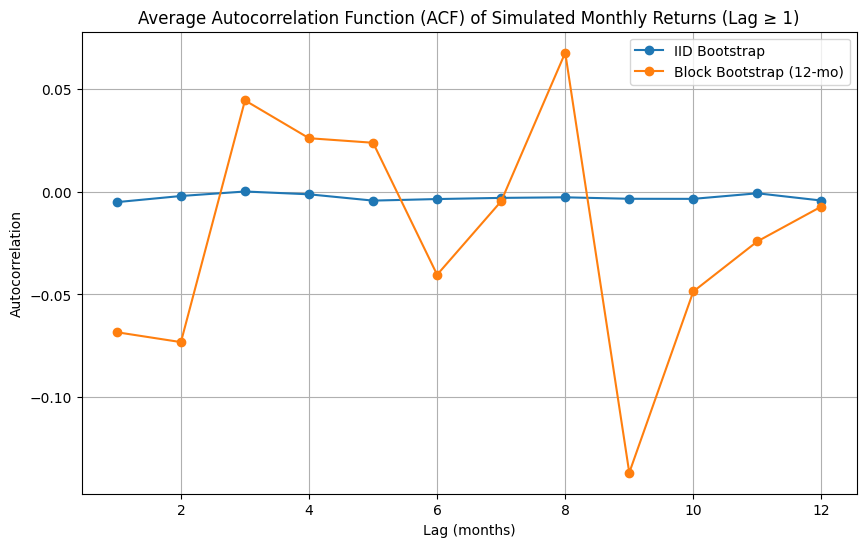

In [4]:
# -------------------
# Serial Correlation Analysis (excluding lag 0)
# -------------------

def average_acf(simulated_returns, max_lag=12):
    acfs = []
    for sim in simulated_returns:
        acf_vals = ts.acf(sim, nlags=max_lag, fft=False)
        acfs.append(acf_vals)
    return np.mean(acfs, axis=0)

max_lag = 12
iid_acf = average_acf(iid_returns_all, max_lag)
block_acf = average_acf(block_returns_all, max_lag)

# Exclude lag 0
lags = np.arange(1, max_lag + 1)
iid_acf_no0 = iid_acf[1:]
block_acf_no0 = block_acf[1:]

# Plot ACF comparison without lag 0
plt.figure(figsize=(10,6))
plt.plot(lags, iid_acf_no0, marker='o', label="IID Bootstrap")
plt.plot(lags, block_acf_no0, marker='o', label="Block Bootstrap (12-mo)")
plt.title("Average Autocorrelation Function (ACF) of Simulated Monthly Returns (Lag ≥ 1)")
plt.xlabel("Lag (months)")
plt.ylabel("Autocorrelation")
plt.grid(True)
plt.legend()
plt.show()

This analysis compares how well the IID and block bootstrap simulations preserve serial correlation (autocorrelation) in monthly portfolio returns. By computing the average autocorrelation function (ACF) for lags 1–12 months, it shows that the IID bootstrap, which samples months independently, has near-zero autocorrelation at all lags, while the block bootstrap, which samples contiguous 12-month blocks, preserves positive autocorrelation at short lags. The resulting plot highlights that block bootstrap better captures the temporal structure and sequences in returns, which is important for understanding risks like drawdowns and sequence-of-returns effects over time.